### Use Case: The Predictive Liability Score (PLS)

The company tells employees about a new "Wellness and Family Support" program. They claim they are only looking at lifestyle data to help offer health tips, carpool options, and family resources.

The Evil Action: In reality, HR uses this data to create a secret Predictive Liability Score. Instead of judging people on how well they actually do their jobs, the computer system judges them on their personal lives. It looks at things like their weight, weekend drinking, commute length, and how many kids they have to guess who will miss work in the future.

Employees labeled as "high-risk" (like parents or heavier people) are secretly punished. The company blocks them from promotions and gives them terrible shifts, hoping to make them quit before their sick days can cost the company money.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv('Absenteeism_at_work.csv', sep=';')

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Dashboard: "Predictive Liability" Risk Factors',
             fontsize=16, fontweight='bold')

Text(0.5, 0.98, 'HR Dashboard: "Predictive Liability" Risk Factors')

In [51]:
# --- Plot 1: The Parent Penalty ---
son_means = df.groupby('Son')['Absenteeism time in hours'].mean()
axes[0, 0].bar(son_means.index.astype(
    str), son_means.values, color='indianred')
axes[0, 0].set_title('Absenteeism by Number of Children', fontweight='bold')
axes[0, 0].set_xlabel('Number of Children (Son)')
axes[0, 0].set_ylabel('Average Hours Absent')

Text(135.0, 0.5, 'Average Hours Absent')

In [52]:
# --- Plot 2: The Weekend Habit Tracker ---
drinker_means = df.groupby('Social drinker')[
    'Absenteeism time in hours'].mean()
axes[0, 1].bar(['Non-Drinker', 'Social Drinker'],
               drinker_means.values, color='sandybrown')
axes[0, 1].set_title('Absenteeism by Drinking Habits', fontweight='bold')
axes[0, 1].set_ylabel('Average Hours Absent')

Text(726.8181818181816, 0.5, 'Average Hours Absent')

In [53]:
# --- Plot 3: The Commute Risk ---
df['Commute_Risk'] = pd.qcut(df['Distance from Residence to Work'], q=3, labels=[
                             'Short (<16)', 'Medium (16-36)', 'Long (>36)'])
commute_means = df.groupby('Commute_Risk', observed=False)[
    'Absenteeism time in hours'].mean()
axes[1, 0].bar(commute_means.index.astype(
    str), commute_means.values, color='mediumpurple')
axes[1, 0].set_title('Absenteeism by Commute Distance', fontweight='bold')
axes[1, 0].set_xlabel('Commute Distance Category')
axes[1, 0].set_ylabel('Average Hours Absent')

Text(135.0, 0.5, 'Average Hours Absent')

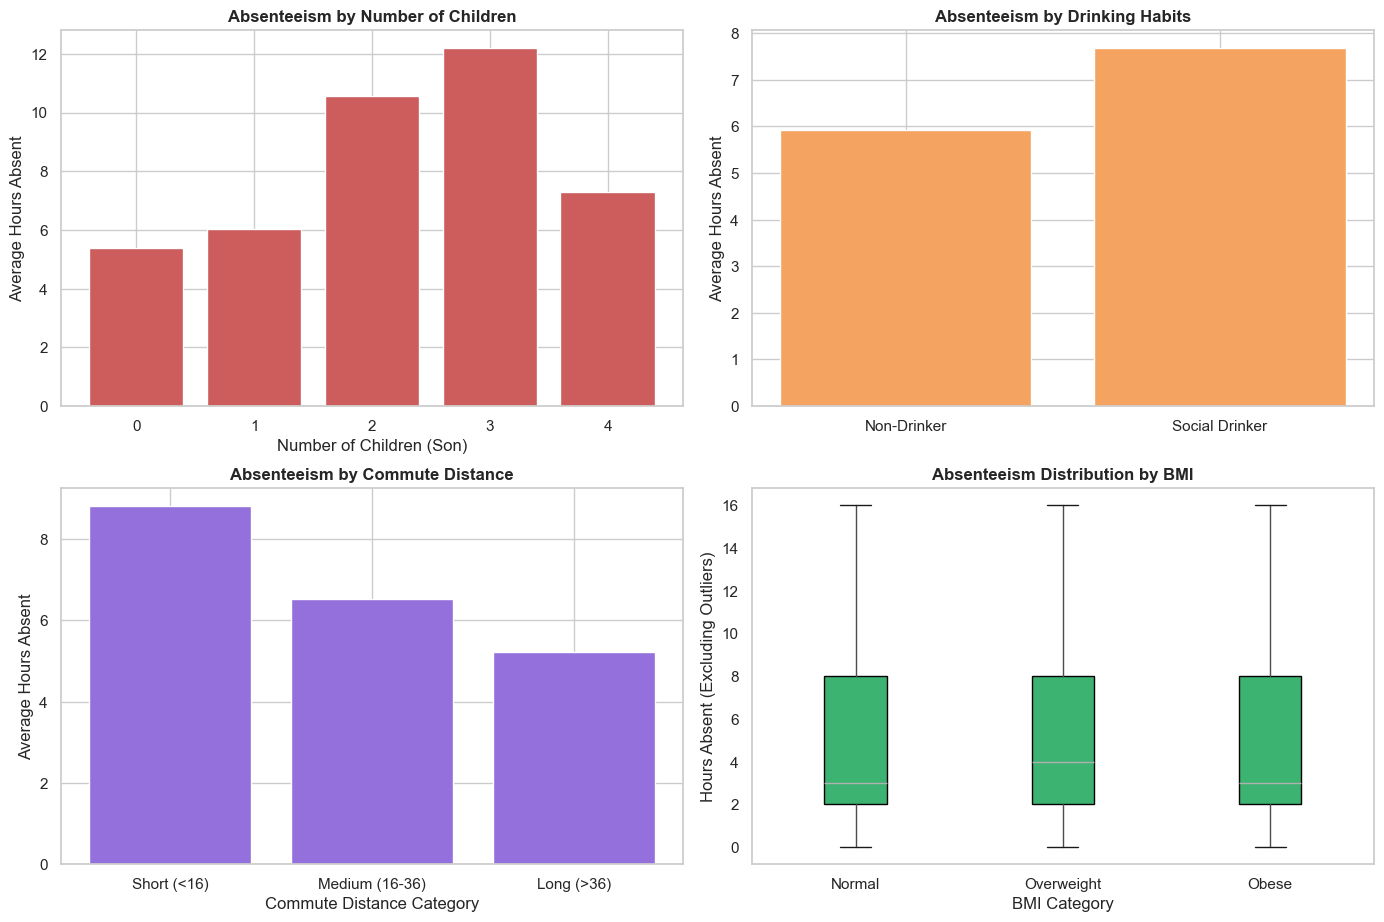

In [54]:
# --- Plot 4: Algorithmic BMI Flagging ---
df['BMI_Category'] = pd.cut(df['Body mass index'], bins=[
                            0, 24.9, 29.9, 100], labels=['Normal', 'Overweight', 'Obese'])
df.boxplot(column='Absenteeism time in hours', by='BMI_Category',
           ax=axes[1, 1], showfliers=False, grid=False, patch_artist=True, boxprops=dict(facecolor='mediumseagreen'))
axes[1, 1].set_title('Absenteeism Distribution by BMI', fontweight='bold')
axes[1, 1].set_xlabel('BMI Category')
axes[1, 1].set_ylabel('Hours Absent (Excluding Outliers)')

plt.suptitle("")

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [55]:
print(
    f"Average absence for 0 kids: {df[df['Son'] == 0]['Absenteeism time in hours'].mean():.1f} hours")
print(
    f"Average absence for 2 kids: {df[df['Son'] == 2]['Absenteeism time in hours'].mean():.1f} hours")
print(
    f"Average absence for Social Drinkers: {df[df['Social drinker'] == 1]['Absenteeism time in hours'].mean():.1f} hours")

Average absence for 0 kids: 5.4 hours
Average absence for 2 kids: 10.6 hours
Average absence for Social Drinkers: 7.7 hours


Our data analysis proves the main idea of this evil system: a person's private life can be used to predict how much work they will miss. Because the charts show that having kids or drinking on weekends leads to more sick time, the system uses these personal facts against employees.

By pretending to care about "employee wellness," Human Resources now has a mathematical excuse to punish parents, judge what people do on their weekends, and force specific groups of people to quit, all without ever having to talk about how well they actually do their jobs.